In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

In [2]:
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype  = "float64"   # usa float64 para Schrödinger (más estable)

print("device:", device, "| dtype:", dtype)



device: cpu | dtype: float64


In [3]:
import importlib

import src.trainer.schrodinger_train as sch_train
import src.nn.ClassicalSolver2 as cs2

importlib.reload(sch_train)
importlib.reload(cs2)

from src.trainer.schrodinger_train import train
from src.nn.ClassicalSolver2 import ClassicalSolver2

from src.problems.schrodinger import build_eq_params, sanity_check
from src.problems.schrodinger.problem import build_problem
from src.utils.logger import Logging


In [4]:
eq_params = build_eq_params(
    "barrier",
    L=1.0,
    T=0.2,
    mass=1.0,
    hbar=1.0,
    n_level=1,
    V0=10.0,
    barrier_width=0.2,
    x_center=0.6,
    num_grid=800,
)

print("eq_params:", eq_params)
print("sanity:", sanity_check(eq_params, device=device))



eq_params: {'example': 'barrier', 'L': 1.0, 'T': 0.2, 'mass': 1.0, 'hbar': 1.0, 'n_level': 1, 'x_min': 0.0, 'x_max': 1.0, 'omega': 1.0, 'V0': 10.0, 'barrier_width': 0.2, 'x_center': 0.6, 'num_grid': 800}
sanity: {'V_min': 0.0, 'V_max': 10.0, 'psi0_norm': 0.9974913794006662, 'psiT_norm': 0.9974913794006662}


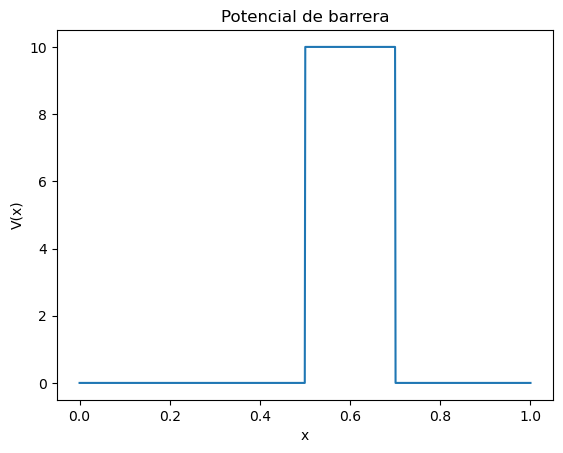

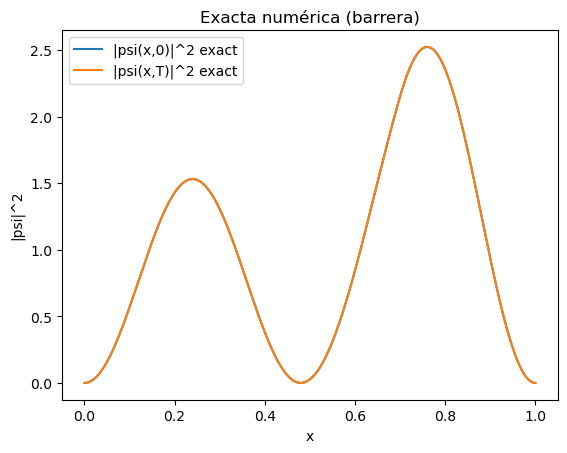

In [5]:
pb = build_problem(eq_params, device=torch.device(device),
                   dtype=torch.float64 if "64" in dtype else torch.float32)

x = torch.linspace(pb["x_min"], pb["x_max"], 900, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    V = pb["potential_fn"](t0, x)
    r0,i0,_ = pb["exact"](pb["n_level"], t0, x)
    rT,iT,_ = pb["exact"](pb["n_level"], tT, x)

x_cpu = x.detach().cpu().numpy().flatten()
V_cpu = V.detach().cpu().numpy().flatten()
p0_cpu = (r0**2 + i0**2).detach().cpu().numpy().flatten()
pT_cpu = (rT**2 + iT**2).detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, V_cpu)
plt.xlabel("x"); plt.ylabel("V(x)")
plt.title("Potencial de barrera")
plt.show()

plt.figure()
plt.plot(x_cpu, p0_cpu, label="|psi(x,0)|^2 exact")
plt.plot(x_cpu, pT_cpu, label="|psi(x,T)|^2 exact")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi|^2")
plt.title("Exacta numérica (barrera)")
plt.show()



In [6]:
args = {
    "eq_params": eq_params,
    "device": device,
    "dtype": dtype,

    "epochs": 3000,
    "lr": 1e-3,
    "batch_size": 64,
    "classic_network": [2, 64, 64, 64, 2],
    "print_every": 100,

    # Barrera: BC dura
    "hard_bc": True,
    "w_bc": 0.0,

    # pesos
    "w_pde": 1.0,
    "w_ic": 300.0,
    "w_norm": 50.0,

    # estabilidad
    "ic_grid": True,
    "warmup_epochs": 400,

    # focus sampling (trainer nuevo)
    "focus_frac": 0.45,
    "focus_margin_frac": 0.30,

    # LBFGS al final (muy útil en barrera)
    "use_lbfgs": False,
    "lbfgs_max_iter": 500,
    "lbfgs_lr": 1.0,

    # opcional (si ves explosiones)
    # "grad_clip": 1.0,
}

logger = Logging("./results/models/checkpoints/smoke_schrodinger", "barrier_Classical")
model = ClassicalSolver2(args, logger, device=torch.device(device))
model.args = args

# chequeo forward
param_dtype = next(model.parameters()).dtype
t_test = torch.rand(8, 1, device=device, dtype=param_dtype) * eq_params["T"]
x_test = torch.rand(8, 1, device=device, dtype=param_dtype) * (eq_params["x_max"] - eq_params["x_min"]) + eq_params["x_min"]
y = model(torch.cat([t_test, x_test], dim=1))
print("forward ok ->", y.shape, y.dtype, y.device)



INFO:src.utils.logger:checkpoint path: self.log_path='./results/models/checkpoints/smoke_schrodinger\\2026-02-03_13-24-40-023749_barrier_Classical'


forward ok -> torch.Size([8, 2]) torch.float64 cpu


In [7]:
train(model, N_f=7000, N_b=500, N_0=800)





INFO:src.utils.logger:It: 1, Loss: 3.581e+02, Loss_res: 2.307e-01,  Loss_bcs: 0.000e+00, Loss_ut_ics: 1.027e+00, Loss_norm: 9.981e-01, Loss_gauge: 0.000e+00, w_pde: 2.50e-03, L^2_error: 9.959e-01, lr: 1.000e-03, Time: 6.28e-01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-03_13-24-40-023749_barrier_Classical\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-03_13-24-40-023749_barrier_Classical\model_weights.pth
INFO:src.utils.logger:It: 100, Loss: 7.917e+01, Loss_res: 2.170e+02,  Loss_bcs: 0.000e+00, Loss_ut_ics: 6.687e-02, Loss_norm: 9.749e-02, Loss_gauge: 0.000e+00, w_pde: 2.50e-01, L^2_error: 1.553e+00, lr: 1.000e-03, Time: 6.07e+01
INFO:src.utils.logger:Model state saved to ./results/models/checkpoints/smoke_schrodinger\2026-02-03_13-24-40-023749_barrier_Classical\model.pth
INFO:src.utils.logger:Model weights saved to ./results/models/checkpoints/smoke_schrodinger\2026-02

L2_rel(T): 0.039924625132831945


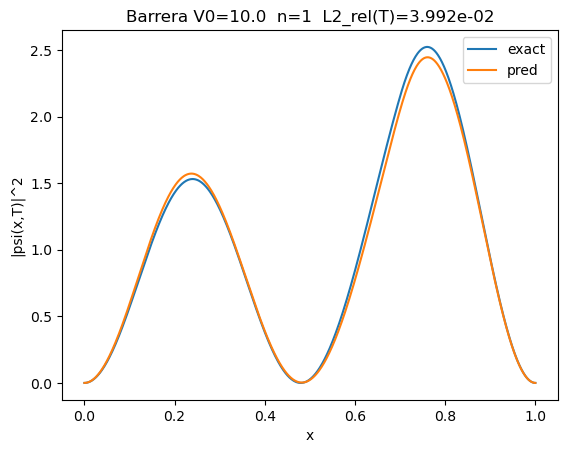

In [8]:
pb = build_problem(eq_params, device=torch.device(device),
                   dtype=torch.float64 if "64" in dtype else torch.float32)

x = torch.linspace(pb["x_min"], pb["x_max"], 900, device=device, dtype=pb["dtype"]).reshape(-1,1)
t = torch.full_like(x, pb["T"])

with torch.no_grad():
    pred = model(torch.cat([t, x], dim=1))
    pr, pi = pred[:,0:1], pred[:,1:2]
    er, ei, _ = pb["exact"](pb["n_level"], t, x)

    l2_abs = torch.sqrt(torch.mean((pr-er)**2 + (pi-ei)**2))
    ref = torch.sqrt(torch.mean(er**2 + ei**2)) + 1e-12
    l2_rel = (l2_abs/ref).item()

print("L2_rel(T):", l2_rel)

prob_pred  = (pr**2 + pi**2).detach().cpu().numpy().flatten()
prob_exact = (er**2 + ei**2).detach().cpu().numpy().flatten()
x_cpu      = x.detach().cpu().numpy().flatten()

plt.figure()
plt.plot(x_cpu, prob_exact, label="exact")
plt.plot(x_cpu, prob_pred,  label="pred")
plt.legend()
plt.xlabel("x"); plt.ylabel("|psi(x,T)|^2")
plt.title(f"Barrera V0={eq_params['V0']}  n={eq_params['n_level']}  L2_rel(T)={l2_rel:.3e}")
plt.show()


In [9]:
pb = build_problem(eq_params, device=torch.device(device), dtype=torch.float64)

x = torch.linspace(pb["x_min"], pb["x_max"], 1400, device=device, dtype=pb["dtype"]).reshape(-1,1)
t0 = torch.zeros_like(x)
tT = torch.full_like(x, pb["T"])

with torch.no_grad():
    p0 = model(torch.cat([t0, x], dim=1))
    pT = model(torch.cat([tT, x], dim=1))

    prob0 = p0[:,0]**2 + p0[:,1]**2
    probT = pT[:,0]**2 + pT[:,1]**2

    norm0 = torch.trapz(prob0, x.squeeze(-1)).item()
    normT = torch.trapz(probT, x.squeeze(-1)).item()

print("Norm pred t=0:", norm0)
print("Norm pred t=T:", normT)



Norm pred t=0: 0.9975911985857356
Norm pred t=T: 0.9847562051683957


In [10]:
import numpy as np

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1,1)
x_grid = torch.linspace(problem["x_min"], problem["x_max"], Nx, device=device_, dtype=dtype_).reshape(-1,1)

# mallado tipo (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1,1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:,0:1], y_pr[:,1:2]

re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

extent = [float(problem["x_min"]), float(problem["x_max"]), float(problem["T"]), 0.0]

plt.figure(figsize=(12,8))

plt.subplot(3,2,1); plt.imshow(re_ex, aspect="auto", extent=extent); plt.title("Re exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,2); plt.imshow(re_pr, aspect="auto", extent=extent); plt.title("Re pred");  plt.colorbar()

plt.subplot(3,2,3); plt.imshow(im_ex, aspect="auto", extent=extent); plt.title("Im exact"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,4); plt.imshow(im_pr, aspect="auto", extent=extent); plt.title("Im pred");  plt.colorbar()

plt.subplot(3,2,5); plt.imshow(re_er, aspect="auto", extent=extent); plt.title("Re error"); plt.xlabel("x"); plt.ylabel("t"); plt.colorbar()
plt.subplot(3,2,6); plt.imshow(im_er, aspect="auto", extent=extent); plt.title("Im error"); plt.xlabel("x"); plt.colorbar()

plt.tight_layout()
plt.show()

NameError: name 'problem' is not defined

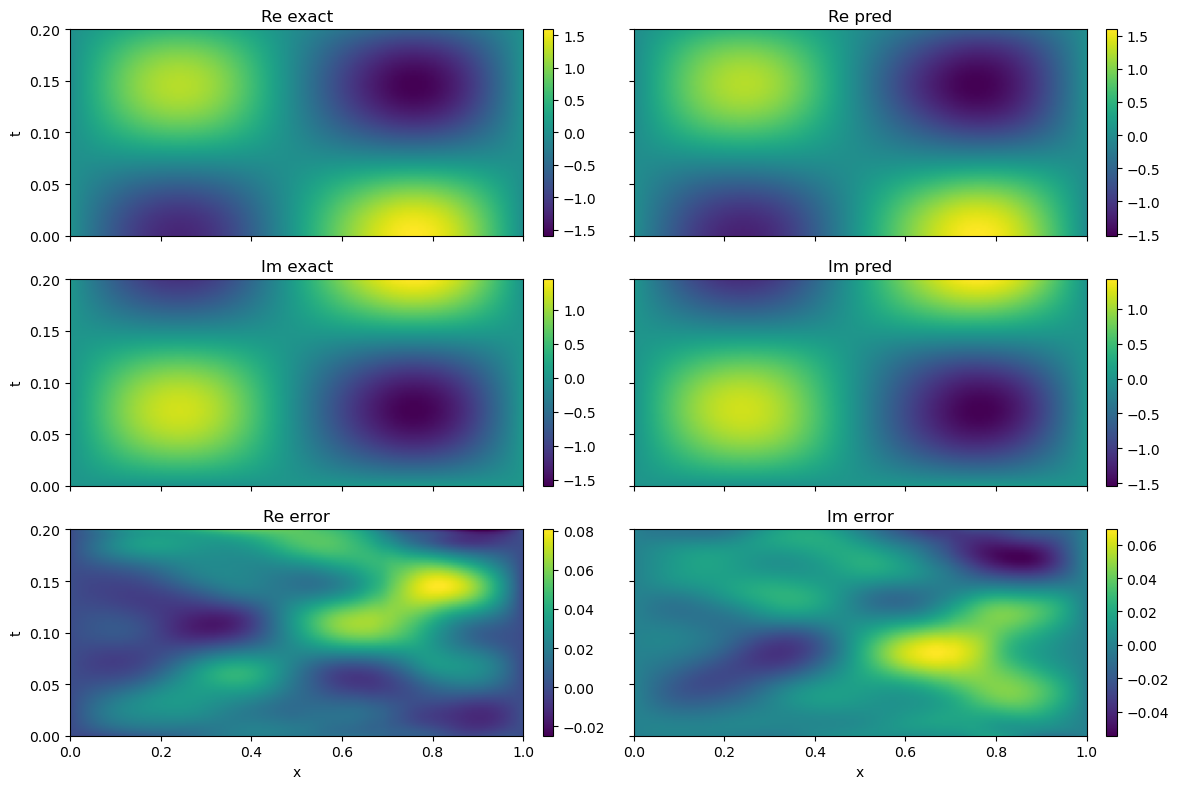

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Usa el problema que ya construiste arriba (pb)
problem = pb

# Consistencia con el modelo (dispositivo y dtype)
device_ = next(model.parameters()).device
dtype_  = next(model.parameters()).dtype

Nt, Nx = 80, 220
t_grid = torch.linspace(0.0, float(problem["T"]), Nt, device=device_, dtype=dtype_).reshape(-1, 1)
x_grid = torch.linspace(float(problem["x_min"]), float(problem["x_max"]), Nx, device=device_, dtype=dtype_).reshape(-1, 1)

# mallado (Nt*Nx, 1)
TT = t_grid.repeat(1, Nx).reshape(-1, 1)
XX = x_grid.repeat(Nt, 1)

with torch.no_grad():
    re_ex, im_ex, _ = problem["exact"](problem["n_level"], TT, XX)
    y_pr = model(torch.cat([TT, XX], dim=1))
    re_pr, im_pr = y_pr[:, 0:1], y_pr[:, 1:2]

# (Nt, Nx) en CPU
re_ex = re_ex.reshape(Nt, Nx).detach().cpu().numpy()
im_ex = im_ex.reshape(Nt, Nx).detach().cpu().numpy()
re_pr = re_pr.reshape(Nt, Nx).detach().cpu().numpy()
im_pr = im_pr.reshape(Nt, Nx).detach().cpu().numpy()

re_er = re_pr - re_ex
im_er = im_pr - im_ex

# Ejes: x horizontal, t vertical
extent = [float(problem["x_min"]), float(problem["x_max"]), 0.0, float(problem["T"])]

fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True, sharey=True)

def show(ax, Z, title):
    h = ax.imshow(Z, aspect="auto", extent=extent, origin="lower")
    ax.set_title(title)
    fig.colorbar(h, ax=ax, fraction=0.046, pad=0.04)

show(axes[0, 0], re_ex, "Re exact")
show(axes[0, 1], re_pr, "Re pred")
show(axes[1, 0], im_ex, "Im exact")
show(axes[1, 1], im_pr, "Im pred")
show(axes[2, 0], re_er, "Re error")
show(axes[2, 1], im_er, "Im error")

for ax in axes[:, 0]:
    ax.set_ylabel("t")
for ax in axes[2, :]:
    ax.set_xlabel("x")

plt.tight_layout()
plt.show()
